In [ ]:
%%capture
if 'google.colab' in str(get_ipython()):
    !pip install --upgrade xee

In [ ]:
!pip install numpy scipy matplotlib
!pip install cython setuptools

In [ ]:
!pip install rasterio
import tarfile
# tar = tarfile.open('/content/drive/MyDrive/Kamatira Model Data/Libraries/pyidw-0.2.20.tar.gz', 'r:gz')
# tar.extractall(path='/content/pyidw_install')
# tar.close()

In [ ]:
# Install wheel (for building packages)
!pip install wheel

# Install required packages using pip
!pip install numpy pandas shapely gdal fiona pyproj six rtree geopandas rasterio pyidw

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [ ]:
!pip install pykrige geopandas rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.6/979.6 kB 10.3 MB/s eta 0:00:00


In [ ]:
import geopandas as gpd
import rasterio
import glob
import pandas as pd
import numpy as np
from rasterio.plot import show
from rasterio.mask import mask
from shapely.geometry import Point
from statsmodels.stats.outliers_influence import variance_inflation_factor
from tqdm import tqdm  # For progress tracking

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point

# Define path to GeoJSON
path3 = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Kamatira.geojson"

# Load the GeoJSON file
gdf_kamatira = gpd.read_file(path3)

# Check its CRS and geometry
print(gdf_kamatira.crs)
print(gdf_kamatira.head())


EPSG:4326
       Name                                        description timestamp  \
0  KAMATIRA  <html xmlns:fo="http://www.w3.org/1999/XSL/For...      None   

  begin   end   altitudeMode  tessellate  extrude  visibility drawOrder  icon  \
0  None  None  clampToGround          -1        0          -1      None  None   

                                            geometry  
0  MULTIPOLYGON Z (((35.16513 1.28577 0, 35.16564...  


In [ ]:
import random

def generate_random_points_within_polygon(polygon, num_points):
    minx, miny, maxx, maxy = polygon.bounds
    points = []

    while len(points) < num_points:
        random_point = Point(random.uniform(minx, maxx), random.uniform(miny, maxy))
        if polygon.contains(random_point):  # Ensure point is inside the polygon
            points.append(random_point)

    return points

# Assuming Kamatira.geojson has a single polygon, else use `unary_union` for multiple polygons
polygon = gdf_kamatira.geometry.unary_union
random_points = generate_random_points_within_polygon(polygon, 1000)

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(geometry=random_points, crs=gdf_kamatira.crs)


<ipython-input-7-96f63cbf1827>:15: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  polygon = gdf_kamatira.geometry.unary_union


In [ ]:
gdf_points.head(3)

,geometry
0,POINT (35.20146 1.25912)
1,POINT (35.23012 1.28338)
2,POINT (35.17509 1.27095)


In [ ]:
gdf_points['Longitude'] = gdf_points.geometry.x
gdf_points['Latitude'] = gdf_points.geometry.y


In [ ]:
gdf_points.head()

,geometry,Longitude,Latitude
0,POINT (35.20146 1.25912),35.201461,1.259115
1,POINT (35.23012 1.28338),35.230118,1.283380
2,POINT (35.17509 1.27095),35.175095,1.270952
3,POINT (35.22575 1.2701),35.225749,1.270099
4,POINT (35.2224 1.26419),35.222403,1.264188


In [ ]:
import requests
import pandas as pd
import time
import os
import geopandas as gpd
from datetime import datetime

# Define the API key and base URL
api_key = "HV8ZYXKJHRFAHLLBRY6EP87PQ"
base_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline"

# Output directory
output_dir = r"/content/drive/MyDrive/Kamatira Model Data/GeoFiles"
os.makedirs(output_dir, exist_ok=True)

# Years to process
years = [1990, 1995, 2000, 2005, 2010, 2015]

# Initialize results list
weather_results = []

# Batch size
batch_size = 100

# Split into batches
total_points = len(gdf_points)
batches = [gdf_points.iloc[i:i+batch_size] for i in range(0, total_points, batch_size)]

print(f"Total points: {total_points}")
print(f"Total batches: {len(batches)}")

# Process each batch
for batch_idx, batch in enumerate(batches):
    print(f"\nStarting batch {batch_idx+1}/{len(batches)} with {len(batch)} points...")

    for index, row in batch.iterrows():
        point_id = row.get('id', index)  # If no 'id' column, use index
        latitude = row['Latitude']
        longitude = row['Longitude']

        print(f"  Processing ID {point_id} ({index + 1}/{total_points})...")

        for year in years:
            start_date = f"{year}-01-01"
            end_date = f"{year}-12-31"

            # Construct the API URL
            url = f"{base_url}/{latitude},{longitude}/{start_date}/{end_date}?unitGroup=metric&include=days&key={api_key}&contentType=json"

            # Make the API call
            response = requests.get(url)

            if response.status_code == 200:
                # Parse the response JSON
                weather_data = response.json()
                daily_data = weather_data.get("days", [])

                if daily_data:
                    df_temp = pd.DataFrame(daily_data)

                    # Calculate annual averages
                    avg_precip = df_temp['precip'].mean()
                    avg_temp = df_temp['temp'].mean()
                    avg_tempmax = df_temp['tempmax'].mean()
                    avg_tempmin = df_temp['tempmin'].mean()

                    weather_results.append({
                        "id": point_id,
                        "Longitude": longitude,
                        "Latitude": latitude,
                        "year": year,
                        "avg_precip": avg_precip,
                        "avg_temp": avg_temp,
                        "avg_tempmax": avg_tempmax,
                        "avg_tempmin": avg_tempmin
                    })
                else:
                    print(f"    No daily data for ID {point_id} in {year}")
            elif response.status_code == 429:
                print(f"    Rate limit hit for ID {point_id} in {year}. Retrying after 60s...")
                time.sleep(60)
                continue
            else:
                print(f"    Error for ID {point_id} in {year}: {response.status_code} - {response.text}")

            time.sleep(1)  # Short delay to avoid rate limit

    print(f"Finished batch {batch_idx+1}/{len(batches)}.")

# After all batches, save results
weather_df = pd.DataFrame(weather_results)

# Generate output filename
file_name = "Annual_Avg_Weather_Batch_Processing_1990_2015.csv"
output_path = os.path.join(output_dir, file_name)

# Save DataFrame to CSV
weather_df.to_csv(output_path, index=False)
print(f"\nAll batches complete! Data exported to: {output_path}")


Total points: 1000
Total batches: 10

Starting batch 1/10 with 100 points...
  Processing ID 0 (1/1000)...
  Processing ID 1 (2/1000)...
  Processing ID 2 (3/1000)...
  Processing ID 3 (4/1000)...
  Processing ID 4 (5/1000)...
  Processing ID 5 (6/1000)...
  Processing ID 6 (7/1000)...
  Processing ID 7 (8/1000)...
  Processing ID 8 (9/1000)...
  Processing ID 9 (10/1000)...
  Processing ID 10 (11/1000)...
  Processing ID 11 (12/1000)...
  Processing ID 12 (13/1000)...
  Processing ID 13 (14/1000)...
  Processing ID 14 (15/1000)...
  Processing ID 15 (16/1000)...
  Processing ID 16 (17/1000)...
  Processing ID 17 (18/1000)...
  Processing ID 18 (19/1000)...
  Processing ID 19 (20/1000)...
  Processing ID 20 (21/1000)...
  Processing ID 21 (22/1000)...
  Processing ID 22 (23/1000)...
  Processing ID 23 (24/1000)...
  Processing ID 24 (25/1000)...
  Processing ID 25 (26/1000)...
  Processing ID 26 (27/1000)...
  Processing ID 27 (28/1000)...
  Processing ID 28 (29/1000)...
  Processing I

In [ ]:
weather_df.head(2)

,id,Longitude,Latitude,year,avg_precip,avg_temp,avg_tempmax,avg_tempmin
0,0,35.201461,1.259115,1990,2.920613,17.914206,24.223677,13.013370
1,0,35.201461,1.259115,1995,3.473973,18.454247,25.281370,12.947945


from matplotlib import pyplot as plt
_df_0['year'].plot(kind='hist', bins=20, title='year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['avg_precip'].plot(kind='hist', bins=20, title='avg_precip')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2['avg_temp'].plot(kind='hist', bins=20, title='avg_temp')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_3['avg_tempmax'].plot(kind='hist', bins=20, title='avg_tempmax')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Longitude']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Longitude'}, axis=1)
              .sort_values('Longitude', ascending=True))
  xs = counted['Longitude']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_11.sort_values('Longitude', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Longitude')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_12['year'].plot(kind='line', figsize=(8, 4), title='year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_13['avg_precip'].plot(kind='line', figsize=(8, 4), title='avg_precip')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_14['avg_temp'].plot(kind='line', figsize=(8, 4), title='avg_temp')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_15['avg_tempmax'].plot(kind='line', figsize=(8, 4), title='avg_tempmax')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
# Save each year's data separately
for year in weather_df['year'].unique():
    df_year = weather_df[weather_df['year'] == year]

    # Define filename
    file_name = f"Annual_Avg_Weather_{year}.csv"
    output_path = os.path.join(output_dir, file_name)

    # Save to CSV
    df_year.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")


Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1990.csv
Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1995.csv
Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2000.csv
Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2005.csv
Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2010.csv
Saved: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2015.csv


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# List the years you have
years = [1990, 1995, 2000, 2005, 2010, 2015]

for year in years:
    # Define paths
    csv_path = os.path.join(output_dir, f"Annual_Avg_Weather_{year}.csv")
    geojson_path = os.path.join(output_dir, f"Annual_Avg_Weather_{year}.geojson")

    # Load CSV
    df = pd.read_csv(csv_path)

    # Create geometry column
    geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=geometry)

    # Set CRS (Coordinate Reference System) - assuming WGS84 (EPSG:4326)
    gdf.set_crs(epsg=4326, inplace=True)

    # Save as GeoJSON
    gdf.to_file(geojson_path, driver='GeoJSON')

    print(f"Saved GeoJSON: {geojson_path}")


Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1990.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1995.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2000.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2005.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2010.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2015.geojson


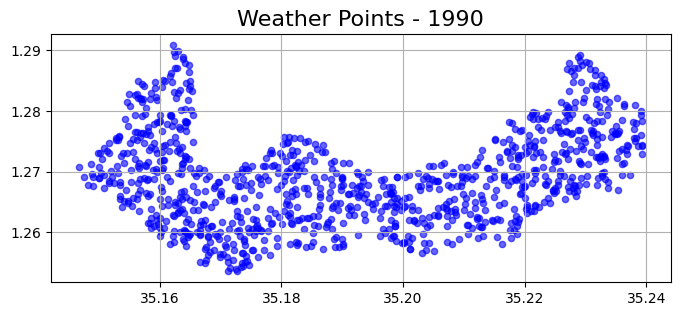

In [ ]:
import matplotlib.pyplot as plt

# Load the 1990 GeoJSON
gdf_1990 = gpd.read_file(os.path.join(output_dir, "Annual_Avg_Weather_1990.geojson"))

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
gdf_1990.plot(ax=ax, color='blue', markersize=20, alpha=0.6)

# Add title and grid
ax.set_title("Weather Points - 1990", fontsize=16)
ax.grid(True)

# Show plot
plt.show()


In [ ]:
import geopandas as gpd
import os

# Paths
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles"
shapefile_dir = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles"

# Make sure the shapefile directory exists
os.makedirs(shapefile_dir, exist_ok=True)

# List of GeoJSON files you saved
geojson_files = [
    "Annual_Avg_Weather_1990.geojson",
    "Annual_Avg_Weather_1995.geojson",
    "Annual_Avg_Weather_2000.geojson",
    "Annual_Avg_Weather_2005.geojson",
    "Annual_Avg_Weather_2010.geojson",
    "Annual_Avg_Weather_2015.geojson"
]

# Loop through each GeoJSON and save as shapefile
for file in geojson_files:
    # Full path to geojson
    geojson_path = os.path.join(geojson_dir, file)

    # Load the GeoJSON
    gdf = gpd.read_file(geojson_path)

    # Define output shapefile path (remove .geojson and add .shp)
    shapefile_name = file.replace(".geojson", ".shp")
    shapefile_path = os.path.join(shapefile_dir, shapefile_name)

    # Save as shapefile
    gdf.to_file(shapefile_path, driver="ESRI Shapefile")

    print(f"Saved Shapefile: {shapefile_path}")


<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(
<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_1990.shp
Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_1995.shp


<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2000.shp


<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2005.shp


<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2010.shp


<ipython-input-42-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2015.shp


In [ ]:
import requests
import pandas as pd
import time
import os
import geopandas as gpd
from datetime import datetime

# Define the API key and base URL
api_key = "API_KEY"
base_url = "https://weather.visualcrossing.com/VisualCrossingWebServices/rest/services/timeline"

# Output directory
output_dir = r"/content/drive/MyDrive/Kamatira Model Data/GeoFiles"
os.makedirs(output_dir, exist_ok=True)

# Years to process
years = [1990, 1995, 2000, 2005, 2010, 2015]

# Initialize results list
weather_results = []

# Assume you have gdf_points already loaded
# gdf_points = gpd.read_file("your_points_file.geojson")

# Batch size
batch_size = 100

# Split into batches
total_points = len(gdf_points)
batches = [gdf_points.iloc[i:i+batch_size] for i in range(0, total_points, batch_size)]

print(f"Total points: {total_points}")
print(f"Total batches: {len(batches)}")

# Process each batch
for batch_idx, batch in enumerate(batches):
    print(f"\nStarting batch {batch_idx+1}/{len(batches)} with {len(batch)} points...")

    for index, row in batch.iterrows():
        point_id = row.get('id', index)  # If no 'id' column, use index
        latitude = row['Latitude']
        longitude = row['Longitude']

        print(f"  Processing ID {point_id} ({index + 1}/{total_points})...")

        for year in years:
            start_date = f"{year}-01-01"
            end_date = f"{year}-12-31"

            # Construct the API URL
            url = f"{base_url}/{latitude},{longitude}/{start_date}/{end_date}?unitGroup=metric&include=days&key={api_key}&contentType=json"

            # Make the API call
            response = requests.get(url)

            if response.status_code == 200:
                # Parse the response JSON
                weather_data = response.json()
                daily_data = weather_data.get("days", [])

                if daily_data:
                    df_temp = pd.DataFrame(daily_data)

                    # Ensure 'datetime' column is proper datetime
                    df_temp['datetime'] = pd.to_datetime(df_temp['datetime'])

                    # Assign quarters
                    df_temp['quarter'] = df_temp['datetime'].dt.to_period('Q')

                    # Group by quarter and calculate averages
                    quarterly_means = df_temp.groupby('quarter').agg({
                        'precip': 'mean',
                        'temp': 'mean',
                        'tempmax': 'mean',
                        'tempmin': 'mean'
                    }).reset_index()

                    # Store results
                    for _, qrow in quarterly_means.iterrows():
                        weather_results.append({
                            "id": point_id,
                            "Longitude": longitude,
                            "Latitude": latitude,
                            "year": year,
                            "quarter": str(qrow['quarter']),  # format like 1990Q1
                            "avg_precip": qrow['precip'],
                            "avg_temp": qrow['temp'],
                            "avg_tempmax": qrow['tempmax'],
                            "avg_tempmin": qrow['tempmin']
                        })
                else:
                    print(f"    No daily data for ID {point_id} in {year}")
            elif response.status_code == 429:
                print(f"    Rate limit hit for ID {point_id} in {year}. Retrying after 60s...")
                time.sleep(60)
                continue
            else:
                print(f"    Error for ID {point_id} in {year}: {response.status_code} - {response.text}")

            time.sleep(1)  # Short delay to avoid rate limit

    print(f"Finished batch {batch_idx+1}/{len(batches)}.")

# After all batches, save results
weather_df = pd.DataFrame(weather_results)

# Generate output filename
file_name = "Quarterly_Avg_Weather_Batch_Processing_1990_2015.csv"
output_path = os.path.join(output_dir, file_name)

# Save DataFrame to CSV
weather_df.to_csv(output_path, index=False)
print(f"\nAll batches complete! Data exported to: {output_path}")


Total points: 1000
Total batches: 10

Starting batch 1/10 with 100 points...
  Processing ID 0 (1/1000)...
  Processing ID 1 (2/1000)...
  Processing ID 2 (3/1000)...
  Processing ID 3 (4/1000)...
  Processing ID 4 (5/1000)...
  Processing ID 5 (6/1000)...
  Processing ID 6 (7/1000)...
  Processing ID 7 (8/1000)...
  Processing ID 8 (9/1000)...
  Processing ID 9 (10/1000)...
  Processing ID 10 (11/1000)...
  Processing ID 11 (12/1000)...
  Processing ID 12 (13/1000)...
  Processing ID 13 (14/1000)...
  Processing ID 14 (15/1000)...
  Processing ID 15 (16/1000)...
  Processing ID 16 (17/1000)...
  Processing ID 17 (18/1000)...
  Processing ID 18 (19/1000)...
  Processing ID 19 (20/1000)...
  Processing ID 20 (21/1000)...
  Processing ID 21 (22/1000)...
  Processing ID 22 (23/1000)...
  Processing ID 23 (24/1000)...
  Processing ID 24 (25/1000)...
  Processing ID 25 (26/1000)...
  Processing ID 26 (27/1000)...
  Processing ID 27 (28/1000)...
  Processing ID 28 (29/1000)...
  Processing I

In [ ]:
import pandas as pd
filepath=r"/content/drive/MyDrive/Kamatira Model Data/GeoFiles/Quarterly_Avg_Weather_Batch_Processing_1990_2015.csv"
df=pd.read_csv(filepath)
df

,id,Longitude,Latitude,year,quarter,avg_precip,avg_temp,avg_tempmax,avg_tempmin
0,0,35.201461,1.259115,1990,1990Q1,2.952222,18.552222,24.940000,13.626667
1,0,35.201461,1.259115,1990,1990Q2,4.129412,17.932941,23.662353,13.842353
2,0,35.201461,1.259115,1990,1990Q3,3.061957,17.059783,23.594565,12.122826
3,0,35.201461,1.259115,1990,1990Q4,1.631522,18.127174,24.670652,12.538043
4,0,35.201461,1.259115,1995,1995Q1,2.162222,19.953333,27.254444,12.753333
...,...,...,...,...,...,...,...,...,...
23995,999,35.161549,1.273449,2010,2010Q4,3.240217,16.963043,24.930435,11.334783
23996,999,35.161549,1.273449,2015,2015Q1,0.551111,20.806667,29.864444,12.214444
23997,999,35.161549,1.273449,2015,2015Q2,10.442857,18.319780,25.586813,14.082418
23998,999,35.161549,1.273449,2015,2015Q3,5.943478,16.604348,24.650000,12.458696


In [ ]:
# Output directory
output_dir = r"/content/drive/MyDrive/Kamatira Model Data/GeoFiles"
os.makedirs(output_dir, exist_ok=True)
# Generate output filename
file_name = "Quarterly_Avg_Weather_Batch_Processing_1990_2015.csv"
output_path = os.path.join(output_dir, file_name)

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import os
# List the years you have
years = [1990, 1995, 2000, 2005, 2010, 2015]

for year in years:
    # Define paths
    csv_path = os.path.join(output_dir, f"Annual_Avg_Weather_{year}.csv")
    geojson_path = os.path.join(output_dir, f"Annual_Avg_Weather_{year}.geojson")


    # Create geometry column
    geometry = [Point(xy) for xy in zip(df['Longitude'], df['Latitude'])]

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(df, geometry=geometry)

    # Set CRS (Coordinate Reference System) - assuming WGS84 (EPSG:4326)
    gdf.set_crs(epsg=4326, inplace=True)

    # Save as GeoJSON
    gdf.to_file(geojson_path, driver='GeoJSON')

    print(f"Saved GeoJSON: {geojson_path}")


Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1990.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_1995.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2000.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2005.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2010.geojson
Saved GeoJSON: /content/drive/MyDrive/Kamatira Model Data/GeoFiles/Annual_Avg_Weather_2015.geojson


In [ ]:
import geopandas as gpd
import os

# Paths
geojson_dir = "/content/drive/MyDrive/Kamatira Model Data/GeoFiles"
shapefile_dir = "/content/drive/MyDrive/Kamatira Model Data/shapeFiles"

# Make sure the shapefile directory exists
os.makedirs(shapefile_dir, exist_ok=True)

# List of GeoJSON files you saved
geojson_files = [
    "Annual_Avg_Weather_1990.geojson",
    "Annual_Avg_Weather_1995.geojson",
    "Annual_Avg_Weather_2000.geojson",
    "Annual_Avg_Weather_2005.geojson",
    "Annual_Avg_Weather_2010.geojson",
    "Annual_Avg_Weather_2015.geojson"
]

# Loop through each GeoJSON and save as shapefile
for file in geojson_files:
    # Full path to geojson
    geojson_path = os.path.join(geojson_dir, file)

    # Load the GeoJSON
    gdf = gpd.read_file(geojson_path)

    # Define output shapefile path (remove .geojson and add .shp)
    shapefile_name = file.replace(".geojson", ".shp")
    shapefile_path = os.path.join(shapefile_dir, shapefile_name)

    # Save as shapefile
    gdf.to_file(shapefile_path, driver="ESRI Shapefile")

    print(f"Saved Shapefile: {shapefile_path}")


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_1990.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_1995.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2000.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(


Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2005.shp


/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(shapefile_path, driver="ESRI Shapefile")
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmax' to 'avg_tempma'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'avg_tempmin' to 'avg_tempmi'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:198: RuntimeWarning: Several features with id = 0 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(
<ipython-input-17-ede54423c526>:34: UserWarning: Column nam

Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2010.shp
Saved Shapefile: /content/drive/MyDrive/Kamatira Model Data/shapeFiles/Annual_Avg_Weather_2015.shp
